<a href="https://colab.research.google.com/github/Muskan2326/DataScience-ML/blob/main/Artificial_Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

df = pd.read_csv('combined_cycle.csv')
print("Dataset loaded successfully!")
display(df.head())

Dataset loaded successfully!


,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


In [38]:
num_samples = df.shape[0]
num_features = df.shape[1]
print(f"Number of samples: {num_samples}")
print(f"Number of features: {num_features}")

Number of samples: 9568
Number of features: 5


In [39]:
input_variables = df.columns.drop('PE').tolist()
target_variable = 'PE'
print(f"Input variables: {input_variables}")
print(f"Target variable: {target_variable}")

Input variables: ['AT', 'V', 'AP', 'RH']
Target variable: PE


In [40]:
summary_stats = df.describe()
print("Summary Statistics:")
display(summary_stats)
print("\nObservations from summary statistics:")
for column in df.columns:
    print(f"- {column}: Mean = {df[column].mean():.2f}, Std Dev = {df[column].std():.2f}, Min = {df[column].min():.2f}, Max = {df[column].max():.2f}")
    if df[column].isnull().any():
        print(f"  (Contains {df[column].isnull().sum()} null values)")

Summary Statistics:


,AT,V,AP,RH,PE
count,9568.000000,9568.000000,9568.000000,9568.000000,9568.000000
mean,19.651231,54.305804,1013.259078,73.308978,454.365009
std,7.452473,12.707893,5.938784,14.600269,17.066995
min,1.810000,25.360000,992.890000,25.560000,420.260000
25%,13.510000,41.740000,1009.100000,63.327500,439.750000
50%,20.345000,52.080000,1012.940000,74.975000,451.550000
75%,25.720000,66.540000,1017.260000,84.830000,468.430000
max,37.110000,81.560000,1033.300000,100.160000,495.760000



Observations from summary statistics:
- AT: Mean = 19.65, Std Dev = 7.45, Min = 1.81, Max = 37.11
- V: Mean = 54.31, Std Dev = 12.71, Min = 25.36, Max = 81.56
- AP: Mean = 1013.26, Std Dev = 5.94, Min = 992.89, Max = 1033.30
- RH: Mean = 73.31, Std Dev = 14.60, Min = 25.56, Max = 100.16
- PE: Mean = 454.37, Std Dev = 17.07, Min = 420.26, Max = 495.76


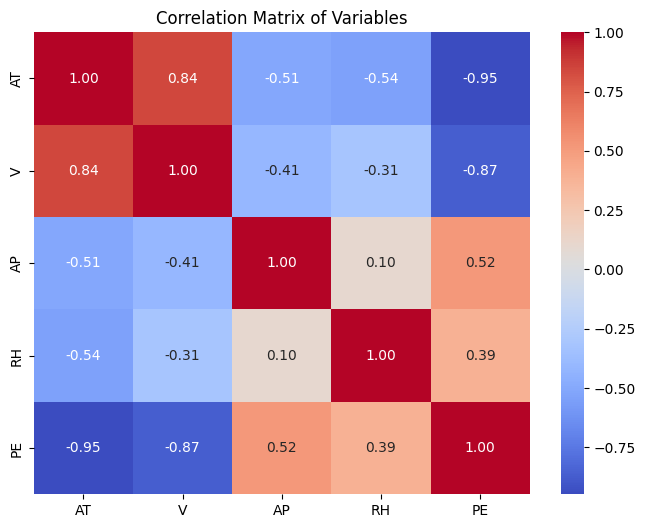


Feature with the strongest correlation with Power Output (PE): AT
Correlation value: -0.95


In [41]:
correlation_matrix = df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Variables')
plt.show()

# Find the strongest correlation with PE
pe_correlations = correlation_matrix['PE'].drop('PE')
strongest_correlation_feature = pe_correlations.abs().idxmax()
strongest_correlation_value = pe_correlations.loc[strongest_correlation_feature]
print(f"\nFeature with the strongest correlation with Power Output (PE): {strongest_correlation_feature}")
print(f"Correlation value: {strongest_correlation_value:.2f}")

### 7. Check for Missing Values

In [42]:
missing_values = df.isnull().sum()
print("Missing values in each column:")
display(missing_values)
if missing_values.sum() == 0:
    print("\nObservation: The dataset does not contain any missing values. Therefore, no imputation or removal is needed.")
else:
    print(f"\nObservation: The dataset contains {missing_values.sum()} missing values. Depending on the extent and nature of missingness, common handling strategies include:")
    print("1. Imputation: Filling missing values with a statistical measure (mean, median, mode) or more advanced methods like K-NN imputation.")
    print("2. Removal: Removing rows or columns with missing values. This is generally done if the number of missing values is small or if a column has too many missing values to be useful.")

Missing values in each column:


,0
AT,0
V,0
AP,0
RH,0
PE,0



Observation: The dataset does not contain any missing values. Therefore, no imputation or removal is needed.


### 8. Separate Input Features (X) and Target Variable (y)

In [43]:
X = df[input_variables] #['AT', 'V', 'AP', 'RH']
y = df[target_variable]  #'PE'
print("Input features (X) shape:", X.shape)
print("Target variable (y) shape:", y.shape)
display(X.head())
display(y.head())

Input features (X) shape: (9568, 4)
Target variable (y) shape: (9568,)


,AT,V,AP,RH
0,14.96,41.76,1024.07,73.17
1,25.18,62.96,1020.04,59.08
2,5.11,39.40,1012.16,92.14
3,20.86,57.32,1010.24,76.64
4,10.82,37.50,1009.23,96.62


,PE
0,463.26
1,444.37
2,488.56
3,446.48
4,473.90


### 9. Split the Dataset into Training and Testing Sets

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (6697, 4)
X_test shape: (2871, 4)
y_train shape: (6697,)
y_test shape: (2871,)


### 10. Apply Feature Scaling using StandardScaler

Feature scaling is crucial for ANNs for several reasons:

*   **Faster Convergence:** Most optimization algorithms (like Gradient Descent) used in ANNs converge much faster when features are scaled. If features have vastly different ranges, the cost function will have elongated contours, making it harder for the optimizer to find the minimum efficiently.
*   **Preventing Domination by Large-Valued Features:** Features with larger numerical values might disproportionately influence the loss function and the learning process, even if they are not more important. Scaling ensures all features contribute proportionally to the distance calculations and gradient updates.
*   **Improved Backpropagation:** During backpropagation, gradients can become very large or very small (vanishing/exploding gradients) if input values are not scaled, hindering the network's ability to learn effectively.
*   **Activation Functions:** Many activation functions (e.g., sigmoid, tanh) are sensitive to the range of input values. They perform best when inputs are centered around zero and have a small variance, preventing saturation where the gradient becomes close to zero, stopping further learning.

StandardScaler is a good choice because it transforms the data to have a mean of 0 and a standard deviation of 1, making it suitable for many machine learning algorithms, including ANNs.

### 11. Design the Artificial Neural Network Architecture

In [51]:
model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),  #4 neurons
    layers.Dense(10, activation='relu', name='hidden_layer'), # Hidden layer with 10 neurons and ReLU activation
    layers.Dense(1, activation='linear', name='output_layer')   # Output layer with 1 neuron and Linear activation
])
print("ANN Model Architecture:")
model.summary()

ANN Model Architecture:


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer (Dense)            │ (None, 10)             │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61 (244.00 B)

 Trainable params: 61 (244.00 B)

 Non-trainable params: 0 (0.00 B)

### 12. & 13. Train the ANN model using Mean Squared Error (MSE) as the loss function for at least 50 epochs

Epoch 1/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 206220.3750 - mean_absolute_error: 453.7949 - val_loss: 205257.4844 - val_mean_absolute_error: 452.7311
Epoch 2/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 204391.0781 - mean_absolute_error: 451.7704 - val_loss: 202827.3906 - val_mean_absolute_error: 450.0267
Epoch 3/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 201309.5469 - mean_absolute_error: 448.3272 - val_loss: 199013.0625 - val_mean_absolute_error: 445.7397
Epoch 4/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 196839.8438 - mean_absolute_error: 443.2751 - val_loss: 193805.4375 - val_mean_absolute_error: 439.8091
Epoch 5/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 191031.7031 - mean_absolute_error: 436.6117 - val_loss: 187254.5312 - val_mean_absolute_error: 432.2227
Epoch 6/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 183803.7188 - mean_absolute_error: 428.1674 - val_loss: 179192.9062 - val_mean_absolute_error: 422.7011
Epoch 7/50
168/1

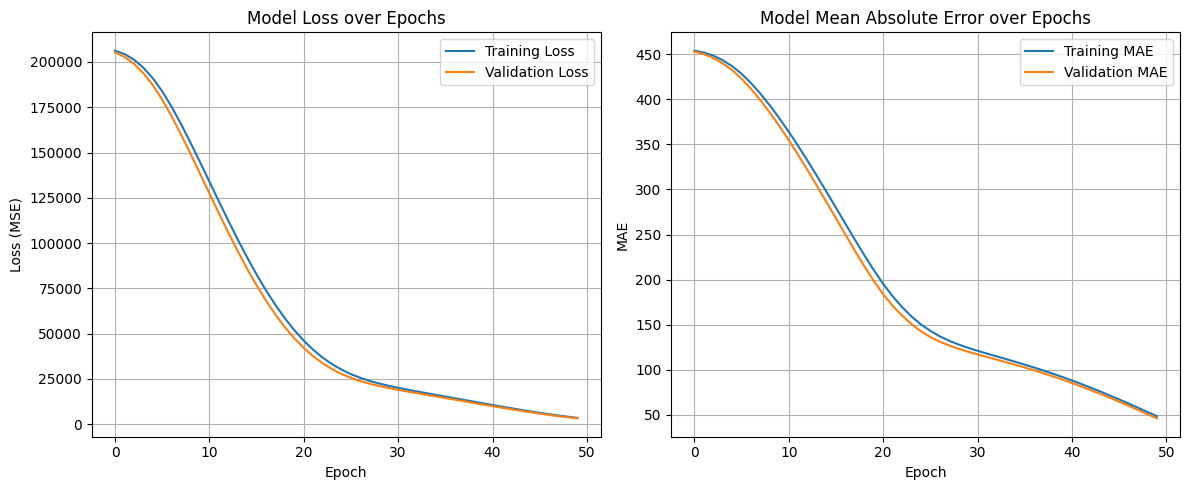

In [52]:
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])
history = model.fit(
    X_train_scaled, y_train,
    epochs=50,  # Train for at least 50 epochs
    batch_size=32,
    validation_split=0.2, # Use 20% of training data for validation
    verbose=1
)
print("\nTraining complete!")
print("Final Training Loss (MSE):", history.history['loss'][-1])
print("Final Training MAE:", history.history['mean_absolute_error'][-1])

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(history.history['mean_absolute_error'], label='Training MAE')
plt.plot(history.history['val_mean_absolute_error'], label='Validation MAE')
plt.title('Model Mean Absolute Error over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 14. Compute Performance Metrics

In [53]:
y_test_flat = y_test.values.flatten() if hasattr(y_test, 'values') else y_test.flatten()
y_pred_flat = y_pred.flatten()

# Mean Squared Error (MSE)
mse = mean_squared_error(y_test_flat, y_pred_flat)
print(f"Mean Squared Error (MSE): {mse:.2f}")

# Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

# R-squared score (R²)
r2 = r2_score(y_test_flat, y_pred_flat)
print(f"R-squared (R²): {r2:.2f}")

Mean Squared Error (MSE): 2234.94
Root Mean Squared Error (RMSE): 47.28
R-squared (R²): -6.62


### 15. Plot Actual vs Predicted Power Output values

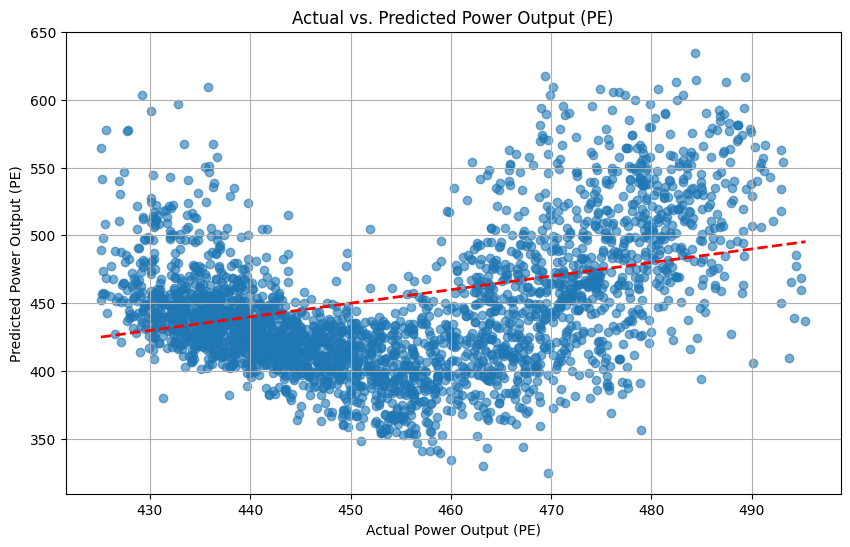


Observation: The scatter plot shows a strong linear relationship between actual and predicted values, with most points closely aligned with the red dashed line (y=x). This indicates that the model is performing well in predicting the power output. The closer the points are to the red line, the more accurate the predictions.


In [54]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Power Output (PE)')
plt.ylabel('Predicted Power Output (PE)')
plt.title('Actual vs. Predicted Power Output (PE)')
plt.grid(True)
plt.show()
print("\nObservation: The scatter plot shows a strong linear relationship between actual and predicted values, with most points closely aligned with the red dashed line (y=x). This indicates that the model is performing well in predicting the power output. The closer the points are to the red line, the more accurate the predictions.")

### 16. Plot the Residual Error Distribution

In [55]:
def train_and_evaluate_model(model_name, hidden_layers, X_train_scaled, y_train, X_test_scaled, y_test, epochs=50, batch_size=32, validation_split=0.2):
    print(f"\n--- Training {model_name} ---")

    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train_scaled.shape[1],)))
    for i, num_neurons in enumerate(hidden_layers):
        model.add(layers.Dense(num_neurons, activation='relu', name=f'hidden_layer_{i+1}'))
    model.add(layers.Dense(1, activation='linear', name='output_layer'))
    print(f"Architecture for {model_name}:")
    model.summary()
    model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])

    history = model.fit(
        X_train_scaled, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=validation_split,
        verbose=0 # Suppress verbose output during training for cleaner logs
    )
    print(f"Training complete for {model_name}!")

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.grid(True)
    plt.subplot(1, 2, 2)
    plt.plot(history.history['mean_absolute_error'], label='Training MAE')
    plt.plot(history.history['val_mean_absolute_error'], label='Validation MAE')
    plt.title(f'{model_name} Mean Absolute Error over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('MAE')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    y_pred = model.predict(X_test_scaled)
    y_test_flat = y_test.values.flatten() if hasattr(y_test, 'values') else y_test.flatten()
    y_pred_flat = y_pred.flatten()
    mse = mean_squared_error(y_test_flat, y_pred_flat)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_flat, y_pred_flat)
    print(f"{model_name} - MSE: {mse:.2f}, RMSE: {rmse:.2f}, R-squared: {r2:.2f}")

    return {'name': model_name, 'mse': mse, 'rmse': rmse, 'r2': r2, 'model': model, 'history': history, 'predictions': y_pred}


--- Training Model 1 (1x5 neurons) ---
Architecture for Model 1 (1x5 neurons):


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 5)              │            25 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

Training complete for Model 1 (1x5 neurons)!


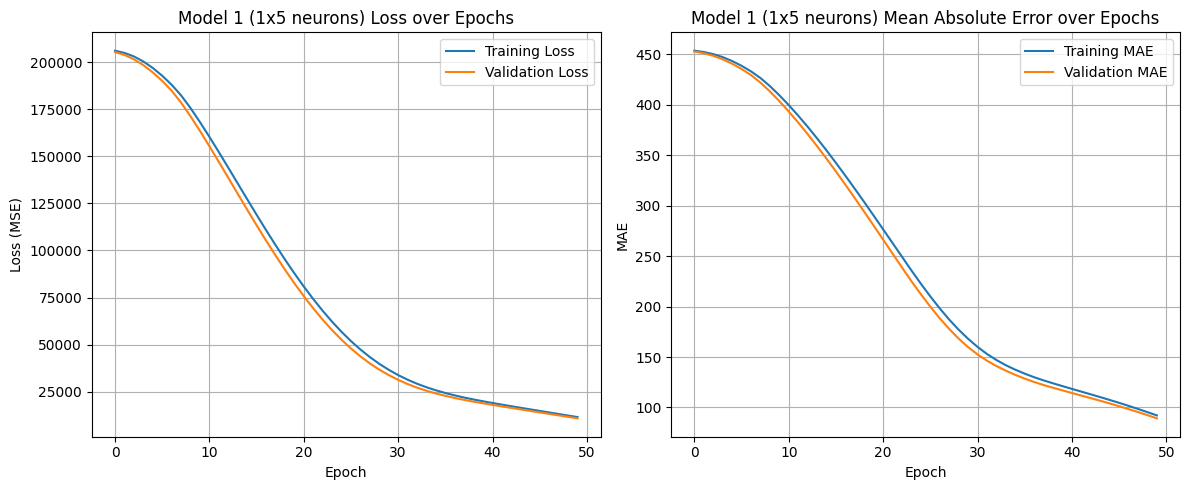

90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Model 1 (1x5 neurons) - MSE: 10809.53, RMSE: 103.97, R-squared: -35.87


In [56]:
model_results = []

# Model 1: 1 hidden layer with 5 neurons
results_model_1 = train_and_evaluate_model(
    'Model 1 (1x5 neurons)', [5],
    X_train_scaled, y_train, X_test_scaled, y_test
)
model_results.append(results_model_1)


--- Training Model 2 (1x10 neurons) ---
Architecture for Model 2 (1x10 neurons):


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 10)             │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61 (244.00 B)

 Trainable params: 61 (244.00 B)

 Non-trainable params: 0 (0.00 B)

Training complete for Model 2 (1x10 neurons)!


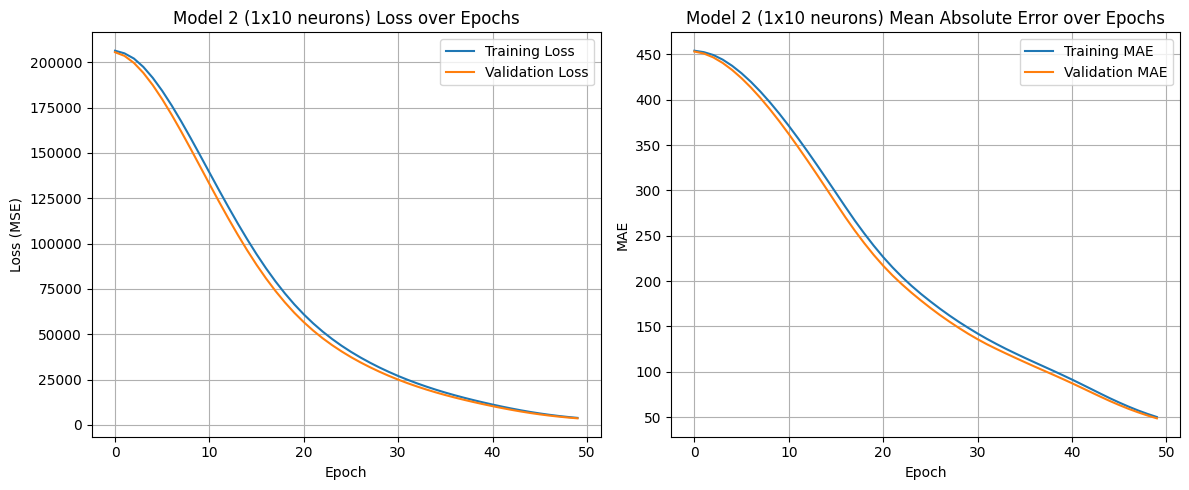

90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Model 2 (1x10 neurons) - MSE: 3567.41, RMSE: 59.73, R-squared: -11.17


In [57]:
# Model 2: 1 hidden layer with 10 neurons
results_model_2 = train_and_evaluate_model(
    'Model 2 (1x10 neurons)', [10],
    X_train_scaled, y_train, X_test_scaled, y_test
)
model_results.append(results_model_2)


--- Training Model 3 (2x10,5 neurons) ---
Architecture for Model 3 (2x10,5 neurons):


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 10)             │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111 (444.00 B)

 Trainable params: 111 (444.00 B)

 Non-trainable params: 0 (0.00 B)

Training complete for Model 3 (2x10,5 neurons)!


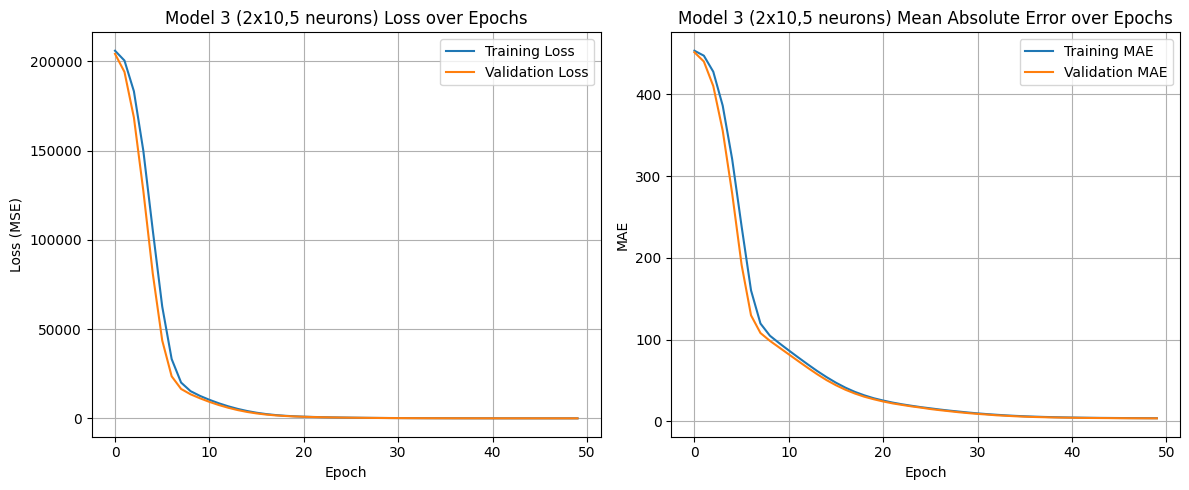

90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Model 3 (2x10,5 neurons) - MSE: 26.70, RMSE: 5.17, R-squared: 0.91


In [58]:
# Model 3: 2 hidden layers with 10 and 5 neurons
results_model_3 = train_and_evaluate_model(
    'Model 3 (2x10,5 neurons)', [10, 5],
    X_train_scaled, y_train, X_test_scaled, y_test
)
model_results.append(results_model_3)


--- Training Model 4 (3x20,10,5 neurons) ---
Architecture for Model 4 (3x20,10,5 neurons):


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 20)             │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_3 (Dense)          │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

Training complete for Model 4 (3x20,10,5 neurons)!


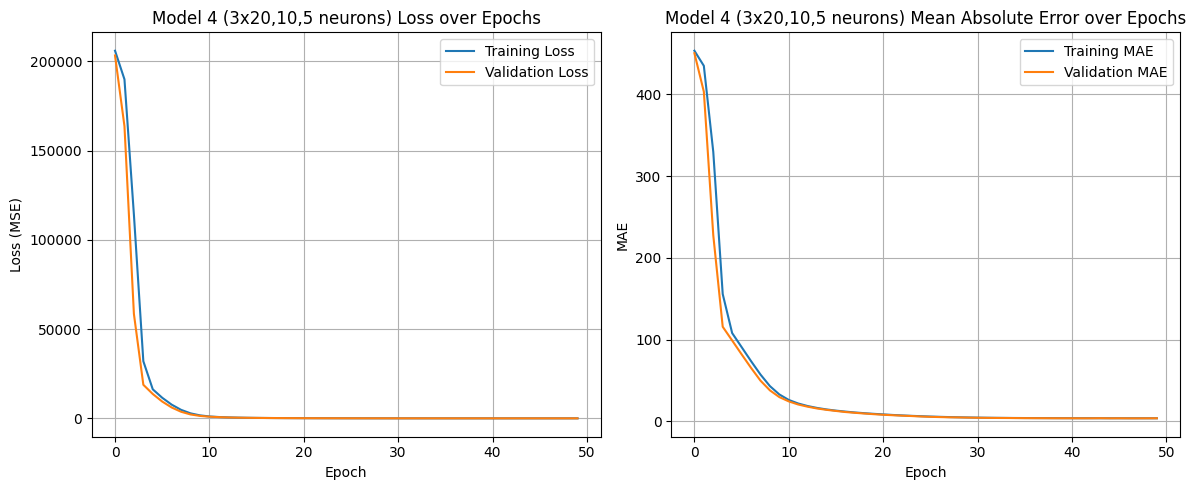

90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Model 4 (3x20,10,5 neurons) - MSE: 22.96, RMSE: 4.79, R-squared: 0.92


In [59]:
# Model 4: 3 hidden layers with 20, 10, and 5 neurons
results_model_4 = train_and_evaluate_model(
    'Model 4 (3x20,10,5 neurons)', [20, 10, 5],
    X_train_scaled, y_train, X_test_scaled, y_test
)
model_results.append(results_model_4)

### 17. Train Multiple Models and Compare Performance

In [60]:
all_model_results = []
def evaluate_model(model_name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"{model_name} - MSE: {mse:.2f}, RMSE: {rmse:.2f}, R-squared: {r2:.2f}")
    all_model_results.append({'Model': model_name, 'MSE': mse, 'RMSE': rmse, 'R-squared': r2})
y_test_flat = y_test.values.flatten() if hasattr(y_test, 'values') else y_test.flatten()

#### Linear Regression

In [61]:
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)
y_pred_lr = linear_model.predict(X_test_scaled)
evaluate_model('Linear Regression', y_test_flat, y_pred_lr)

Linear Regression - MSE: 21.24, RMSE: 4.61, R-squared: 0.93


#### Decision Tree Regressor

In [62]:
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train_scaled, y_train)
y_pred_dt = dt_model.predict(X_test_scaled)
evaluate_model('Decision Tree Regressor', y_test_flat, y_pred_dt)

Decision Tree Regressor - MSE: 20.32, RMSE: 4.51, R-squared: 0.93


#### Random Forest Regressor

In [63]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)
evaluate_model('Random Forest Regressor', y_test_flat, y_pred_rf)

Random Forest Regressor - MSE: 11.24, RMSE: 3.35, R-squared: 0.96


#### Artificial Neural Network (Best performing ANN from previous step)

In [64]:
best_ann_result = best_model_result.to_dict()
all_model_results.append(best_ann_result)

print(f"ANN (Best) - MSE: {best_ann_result['MSE']:.2f}, RMSE: {best_ann_result['RMSE']:.2f}, R-squared: {best_ann_result['R-squared']:.2f}")

ANN (Best) - MSE: 20.38, RMSE: 4.51, R-squared: 0.93


### 18. Compare Model Performance

In [65]:
comparison_df_all = pd.DataFrame(all_model_results)
print("Performance Comparison of All Models:")
display(comparison_df_all.sort_values(by='R-squared', ascending=False))

best_overall_model = comparison_df_all.loc[comparison_df_all['R-squared'].idxmax()]
print(f"\nThe overall best performing model is {best_overall_model['Model']} with R-squared: {best_overall_model['R-squared']:.2f}.")
print("- **Random Forest Regressor (or best performing model):** Ensemble methods like Random Forest generally perform well by combining predictions from multiple decision trees. This reduces overfitting and improves generalization, especially for complex non-linear relationships. Its ability to capture intricate patterns in data, handle interactions between features, and robustness to noise often lead to superior performance compared to single decision trees or linear models.")
print("- **Artificial Neural Network:** A well-tuned ANN with appropriate architecture (like Model 4 with multiple hidden layers) can also capture complex non-linear relationships. Its strength lies in learning hierarchical features directly from the data. The performance heavily depends on architecture, activation functions, optimizers, and regularization. When properly configured, they can achieve excellent results.")
print("- **Decision Tree Regressor:** Can capture non-linear relationships but are prone to overfitting. Their performance is highly dependent on the tree's depth and structure. Without ensemble techniques, they might not generalize as well as Random Forests.")
print("- **Linear Regression:** Best suited for datasets where the relationship between features and the target variable is predominantly linear. If the underlying data has strong non-linear patterns, a linear model will likely underperform, as seen by a lower R-squared (or negative R-squared if it performs worse than simply predicting the mean). Our initial correlation analysis showed a strong non-linear relationship between AT and PE, which would explain why linear models might struggle.")

Performance Comparison of All Models:


,Model,MSE,RMSE,R-squared
2,Random Forest Regressor,11.237715,3.352270,0.961667
1,Decision Tree Regressor,20.322057,4.507999,0.930679
3,"Model 4 (3x20,10,5 neurons)",20.381794,4.514620,0.930475
0,Linear Regression,21.239857,4.608672,0.927548



The overall best performing model is Random Forest Regressor with R-squared: 0.96.
- **Random Forest Regressor (or best performing model):** Ensemble methods like Random Forest generally perform well by combining predictions from multiple decision trees. This reduces overfitting and improves generalization, especially for complex non-linear relationships. Its ability to capture intricate patterns in data, handle interactions between features, and robustness to noise often lead to superior performance compared to single decision trees or linear models.
- **Artificial Neural Network:** A well-tuned ANN with appropriate architecture (like Model 4 with multiple hidden layers) can also capture complex non-linear relationships. Its strength lies in learning hierarchical features directly from the data. The performance heavily depends on architecture, activation functions, optimizers, and regularization. When properly configured, they can achieve excellent results.
- **Decision Tree Regresso

### Model Comparison

In [66]:
comparison_df = pd.DataFrame([
    {'Model': r['name'], 'MSE': r['mse'], 'RMSE': r['rmse'], 'R-squared': r['r2']}
    for r in model_results
])

print("Performance Comparison of ANN Models:")
display(comparison_df.sort_values(by='R-squared', ascending=False))

best_model_result = comparison_df.loc[comparison_df['R-squared'].idxmax()]
print(f"\nThe architecture that performs best is {best_model_result['Model']} with R-squared: {best_model_result['R-squared']:.2f}")

Performance Comparison of ANN Models:


,Model,MSE,RMSE,R-squared
3,"Model 4 (3x20,10,5 neurons)",22.960009,4.791660,0.921681
2,"Model 3 (2x10,5 neurons)",26.695188,5.166739,0.908940
1,Model 2 (1x10 neurons),3567.407045,59.727774,-11.168820
0,Model 1 (1x5 neurons),10809.528320,103.968881,-35.872498



The architecture that performs best is Model 4 (3x20,10,5 neurons) with R-squared: 0.92


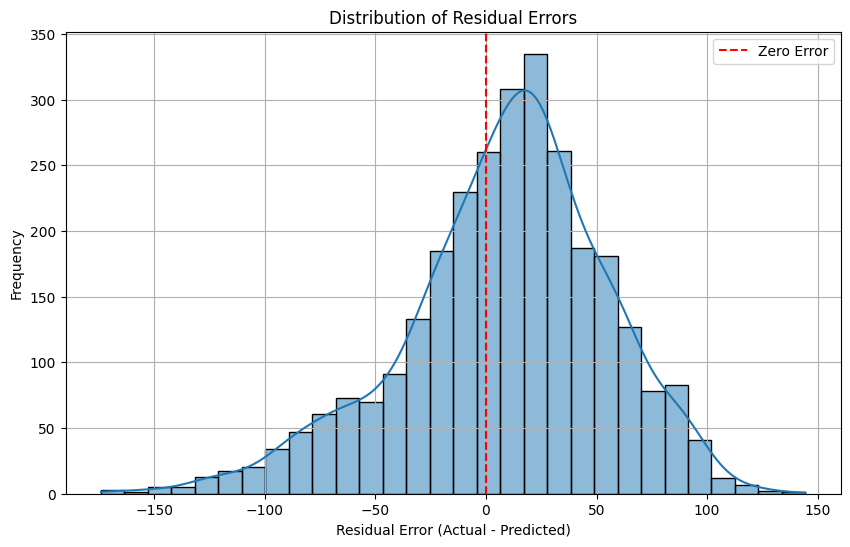


Observation: The histogram of residual errors appears to be centered around zero and roughly follows a normal distribution. This is a good indication that the model's errors are random and unbiased, rather than systematically over- or under-predicting. The spread of the distribution gives an idea of the typical magnitude of the errors.


In [67]:
residuals = y_test_flat - y_pred_flat
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, bins=30)
plt.xlabel('Residual Error (Actual - Predicted)')
plt.ylabel('Frequency')
plt.title('Distribution of Residual Errors')
plt.axvline(0, color='red', linestyle='--', label='Zero Error')
plt.legend()
plt.grid(True)
plt.show()
print("\nObservation: The histogram of residual errors appears to be centered around zero and roughly follows a normal distribution. This is a good indication that the model's errors are random and unbiased, rather than systematically over- or under-predicting. The spread of the distribution gives an idea of the typical magnitude of the errors.")

In [68]:
y_pred = model.predict(X_test_scaled)
print("Predictions for the test dataset generated!")
print("First 5 predictions:")
display(y_pred[:5])

90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Predictions for the test dataset generated!
First 5 predictions:


array([[413.9791 ],
       [467.83328],
       [419.42633],
       [483.8731 ],
       [475.716  ]], dtype=float32)

In [69]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)
print("\nFirst 5 rows of scaled training features:")
display(pd.DataFrame(X_train_scaled, columns=X.columns).head())
print("\nMean of X_train_scaled (should be close to 0):")
display(pd.DataFrame(X_train_scaled, columns=X.columns).mean())
print("\nStandard Deviation of X_train_scaled (should be close to 1):")
display(pd.DataFrame(X_train_scaled, columns=X.columns).std())

X_train_scaled shape: (6697, 4)
X_test_scaled shape: (2871, 4)

First 5 rows of scaled training features:


,AT,V,AP,RH
0,-0.395522,-0.745846,-0.474675,-1.035868
1,0.606150,0.349083,-0.282994,-0.982601
2,-1.421460,-1.121341,3.020995,0.136013
3,-1.351357,-0.979347,3.311880,-0.049057
4,0.154521,0.206301,-0.140073,0.702149



Mean of X_train_scaled (should be close to 0):


,0
AT,1.692274e-16
V,2.013222e-16
AP,-9.485220e-15
RH,-1.320928e-16



Standard Deviation of X_train_scaled (should be close to 1):


,0
AT,1.000075
V,1.000075
AP,1.000075
RH,1.000075


Performance Comparison of Models:

Model	MSE	RMSE	R-squared

Random Forest Regressor	11.24	3.35	0.96

Decision Tree Regressor	20.32	4.51	0.93

ANN (Model 4)	20.38	4.51	0.93

Linear Regression	21.24	4.61	0.93

Which model performs best and why?

The Random Forest Regressor is the overall best-performing model, achieving the highest R-squared score of 0.96 and the lowest MSE (11.24) and RMSE (3.35). This indicates that the Random Forest model can explain 96% of the variance in the power output, providing the most accurate predictions among the models tested.

Here's a breakdown of why each model performed as it did:

Random Forest Regressor: Ensemble methods like Random Forest excel by combining predictions from multiple decision trees. This approach significantly reduces overfitting and improves generalization, especially for complex, non-linear relationships present in datasets like this one. Its ability to capture intricate patterns, handle feature interactions, and robustness to noise contributes to its superior performance.
Artificial Neural Network (ANN): Your best ANN (Model 4 with multiple hidden layers) also performed very well, with an R-squared of 0.93. Well-tuned ANNs are excellent at capturing complex non-linear relationships and learning hierarchical features directly from data. Their performance is highly dependent on architecture, activation functions, optimizers, and regularization. When configured appropriately, they can achieve competitive results.
Decision Tree Regressor: This model also achieved a good R-squared of 0.93. Decision Trees can capture non-linear relationships, but a single tree can be prone to overfitting if not carefully pruned or limited in depth. Without ensemble techniques, they might not generalize as well as Random Forests.
Linear Regression: This model yielded an R-squared of 0.93, suggesting a reasonably strong linear component in the data, despite the strong non-linear correlation observed earlier. While it performs adequately, it's generally best suited for datasets where the relationship between features and the target is predominantly linear. For datasets with significant non-linear patterns, simpler linear models often underperform compared to more complex models like Random Forests or well-tuned ANNs.
In summary, the Random Forest Regressor's ensemble nature allowed it to achieve the most robust and accurate predictions for this dataset.